In [ ]:
import pickle
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent
MODEL_DIR = PROJECT_ROOT / "models"

model_names = ["RW", "DNS", "Ridge", "XGBoost"]

model_preds = {}
model_actuals = {}
model_metrics = {}

for name in model_names:
    path = MODEL_DIR / f"{name}.pkl"
    with open(path, "rb") as f:
        bundle = pickle.load(f)

    print(f"Loaded {name} from {path}, keys: {list(bundle.keys())}")

    model_preds[name]   = bundle["predictions"]
    model_actuals[name] = bundle["actuals"]
    model_metrics[name] = bundle["metrics"]   # <--- NEW

print("Models loaded:", list(model_preds.keys()))


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\mango\\Desktop\\Bachelorarbeit\\models\\RW.pkl'

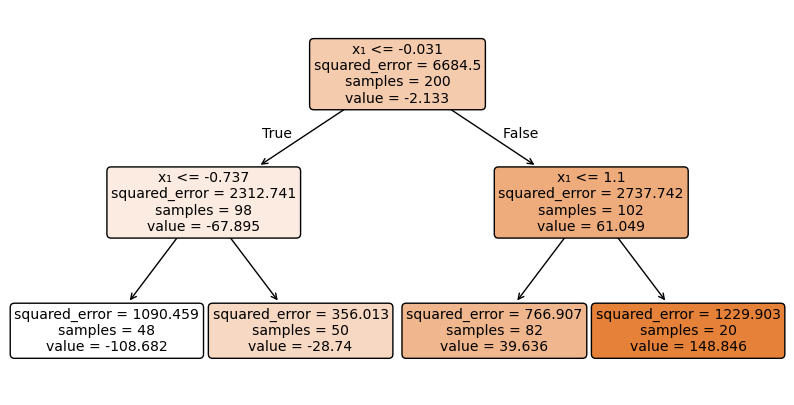

In [2]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

# Generate small synthetic regression dataset
X, y = make_regression(n_samples=200, n_features=1, noise=10, random_state=42)

# Fit a shallow regression tree (max depth = 2)
tree = DecisionTreeRegressor(max_depth=2, random_state=42)
tree.fit(X, y)

# Plot decision tree
plt.figure(figsize=(10, 5))
plot_tree(
    tree,
    filled=True,
    feature_names=["x₁"],
    impurity=True,
    precision=3,
    rounded=True,
)
plt.axis("off")  # remove border/heading axes
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Helper: get canonical actual series for a given (maturity, horizon)
# We use RW's actuals as canonical (they're aligned with others).
# -------------------------------------------------------------------
def get_actual_series(maturity, horizon):
    key = (maturity, horizon)
    if "RW" not in model_actuals:
        # fallback: take first model that has this key
        for m in model_actuals:
            if key in model_actuals[m]:
                return model_actuals[m][key]
        raise KeyError(f"No actual series found for {key}")
    return model_actuals["RW"][key]


# ================================================================
# FIGURE 1:
# All models vs Actual in one plot
# ================================================================
def plot_all_models_vs_actual(
    maturity="DGS10",
    horizon=10,
    N=200,
    models=("RW", "DNS", "Ridge", "XGBoost")
):
    """
    Plot Actual vs multiple models for a given maturity & horizon,
    using the last N common observations.
    """
    key = (maturity, horizon)
    actual = get_actual_series(maturity, horizon).rename("Actual")

    # Collect model predictions and align
    series_dict = {"Actual": actual}
    for model in models:
        pred_dict = model_preds.get(model, {})
        if key not in pred_dict:
            print(f"[WARN] {model} has no predictions for {key}, skipping.")
            continue
        series_dict[model] = pred_dict[key].rename(model)

    df = pd.concat(series_dict.values(), axis=1, join="inner").dropna()
    if df.empty:
        raise ValueError(f"No common dates for {key} across selected models.")

    # Keep last N observations
    df = df.iloc[-N:]

    plt.figure(figsize=(12, 5))
    for col in df.columns:
        if col == "Actual":
            plt.plot(df.index, df[col], label=col, linewidth=1.8)
        else:
            plt.plot(df.index, df[col], label=col, linestyle="--", linewidth=1.0)

    plt.title(f"{maturity} | h = {horizon} days – Actual vs Models")
    plt.xlabel("Date")
    plt.ylabel("Yield (%)")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ================================================================
# FIGURE 2:
# One subplot per model vs Actual
# ================================================================
def plot_models_vs_actual_subplots(
    maturity="DGS2",
    horizon=5,
    N=200,
    models=("RW", "DNS", "Ridge", "XGBoost")
):
    """
    Create a 1×K subplot figure: for each model, show Actual vs that model.
    """
    key = (maturity, horizon)
    actual = get_actual_series(maturity, horizon).rename("Actual")

    # Filter models that actually have predictions
    valid_models = []
    for model in models:
        pred_dict = model_preds.get(model, {})
        if key in pred_dict:
            valid_models.append(model)
        else:
            print(f"[WARN] {model} has no predictions for {key}, skipping.")

    if not valid_models:
        raise ValueError(f"No models with predictions for {key}.")

    n_models = len(valid_models)
    fig, axes = plt.subplots(
        nrows=1,
        ncols=n_models,
        figsize=(4 * n_models, 4),
        sharex=True,
        sharey=True
    )

    if n_models == 1:
        axes = [axes]

    for ax, model in zip(axes, valid_models):
        pred_s = model_preds[model][key].rename(model)

        df = pd.concat([actual, pred_s], axis=1, join="inner").dropna()
        if df.empty:
            ax.set_title(f"{model} (no common data)")
            continue

        df = df.iloc[-N:]

        ax.plot(df.index, df["Actual"], label="Actual", linewidth=1.5)
        ax.plot(df.index, df[model], label=model, linestyle="--", linewidth=1.0)

        ax.set_title(f"{model}")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=45)

    axes[0].set_ylabel("Yield (%)")
    axes[0].legend(loc="upper left")
    fig.suptitle(f"{maturity} | h = {horizon} days – Actual vs each model", y=1.02)
    plt.tight_layout()
    plt.show()


# ================================================================
# FIGURE 3:
# Yield curve shape comparison (2y, 5y, 10y) at a given horizon & date
# ================================================================
def plot_yield_curve_comparison(
    horizon=10,
    eval_date=None,
    maturities=("DGS2", "DGS5", "DGS10"),
    maturities_years=(2, 5, 10),
    models=("RW", "DNS", "Ridge", "XGBoost")
):
    """
    Plot actual and model-predicted yield curves (2y, 5y, 10y)
    for a single forecast date (horizon fixed).

    If eval_date is None, use the last date that is common
    across all models & maturities for this horizon.
    """
    h = horizon
    keys = [(m, h) for m in maturities]

    # Build dict of series for each model & maturity
    # and find common forecast dates
    model_dates = []

    # First, collect actuals
    actual_series = {}
    for m in maturities:
        actual_series[m] = get_actual_series(m, h)
        model_dates.append(set(actual_series[m].index))

    # Then, collect predictions
    for model in models:
        pred_dict = model_preds.get(model, {})
        for m in maturities:
            key = (m, h)
            if key not in pred_dict:
                print(f"[WARN] {model} missing {key}, will be partially missing.")
                continue
            model_dates.append(set(pred_dict[key].index))

    # Determine common dates across everything we actually have
    common = set.intersection(*model_dates) if model_dates else set()
    if not common:
        raise ValueError(f"No common forecast dates for horizon {h} across series.")

    if eval_date is None:
        eval_date = max(common)  # last common date

    if eval_date not in common:
        raise ValueError(f"Chosen eval_date {eval_date} not in common forecast dates.")

    eval_date = pd.Timestamp(eval_date)

    # Build curves
    actual_curve = []
    model_curves = {m: [] for m in models}

    for m in maturities:
        # Actual yield (level) at eval_date
        try:
            actual_curve.append(actual_series[m].loc[eval_date])
        except KeyError:
            actual_curve.append(np.nan)

        for model in models:
            pred_dict = model_preds.get(model, {})
            key = (m, h)
            if key in pred_dict and eval_date in pred_dict[key].index:
                model_curves[model].append(pred_dict[key].loc[eval_date])
            else:
                model_curves[model].append(np.nan)

    # Plot
    x = np.array(maturities_years, dtype=float)

    plt.figure(figsize=(8, 5))
    plt.plot(x, actual_curve, marker="o", linewidth=2, label="Actual")

    for model in models:
        plt.plot(x, model_curves[model], marker="o", linestyle="--", linewidth=1.2, label=model)

    plt.title(f"Yield Curve Comparison at horizon h={h}, date={eval_date.date()}")
    plt.xlabel("Maturity (years)")
    plt.ylabel("Yield (%)")
    plt.xticks(x, maturities_years)
    plt.legend()
    plt.tight_layout()
    plt.show()
